<a href="https://colab.research.google.com/github/haujla2391/CSCI-4170/blob/main/03_rec_sys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Super MOVIE Analyzer Pro++ (CUDA Edition)

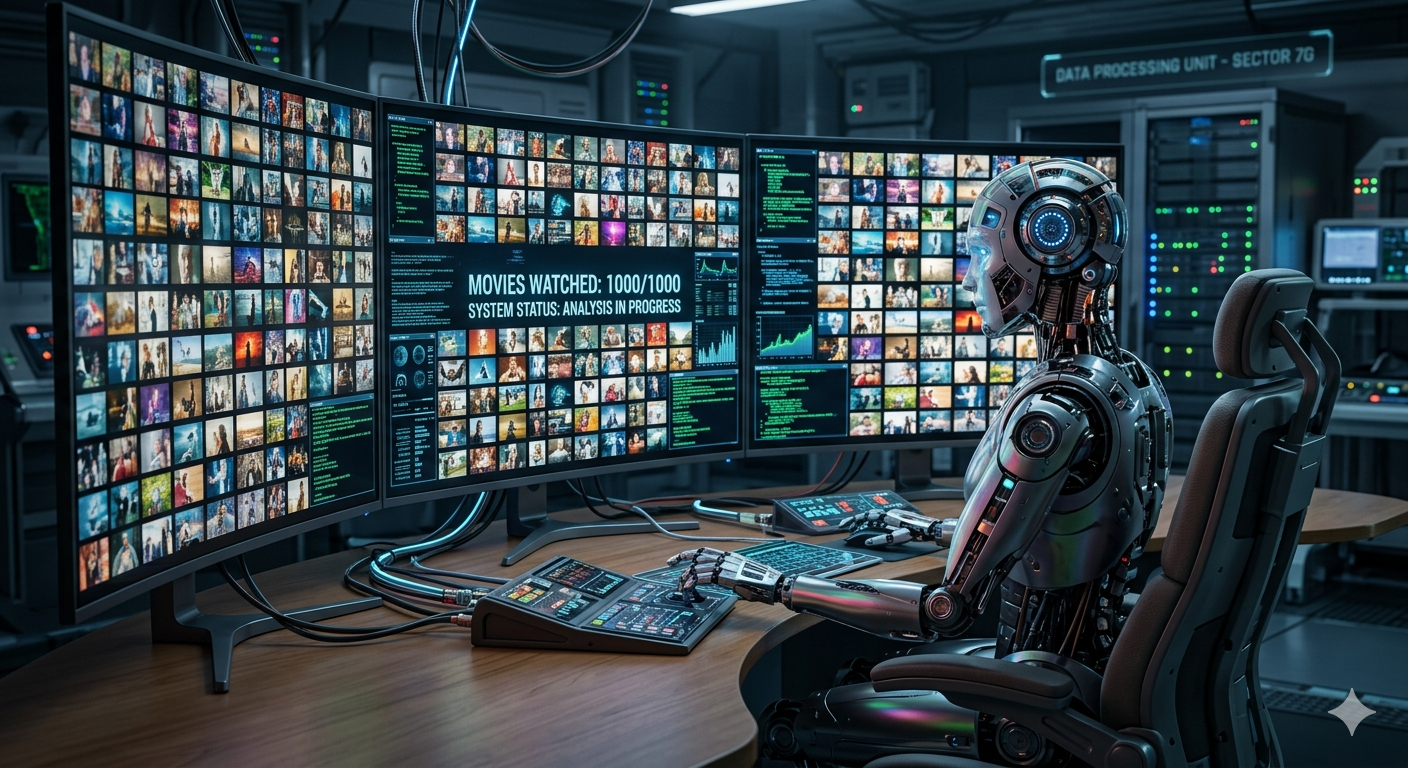

In [ ]:
from IPython.display import Image, display
display(Image(filename='/content/Gemini_Generated_Image_8fywsc8fywsc8fyw.png'))


Loaded MovieLens 100K: 100,000 ratings, 943 users, 1682 items
Global mean baseline: 3.5319
Baseline RMSE: 1.1303
Training Matrix Factorization
Epoch  5  Loss: 21.9018
Epoch 10  Loss: 20.8155
Epoch 15  Loss: 19.7887
Epoch 20  Loss: 18.8204
Epoch 25  Loss: 17.9081
Epoch 30  Loss: 17.0490
Epoch 35  Loss: 16.2395
Epoch 40  Loss: 15.4755
Epoch 45  Loss: 14.7530
Epoch 50  Loss: 14.0679
Epoch 55  Loss: 13.4162
Epoch 60  Loss: 12.7940
Epoch 65  Loss: 12.1977
Epoch 70  Loss: 11.6239
Epoch 75  Loss: 11.0696
Epoch 80  Loss: 10.5321
Epoch 85  Loss: 10.0093
Epoch 90  Loss: 9.4994
Epoch 95  Loss: 9.0013
Epoch 100  Loss: 8.5147
Epoch 105  Loss: 8.0396
Epoch 110  Loss: 7.5767
Epoch 115  Loss: 7.1273
Epoch 120  Loss: 6.6928
Epoch 125  Loss: 6.2748
Epoch 130  Loss: 5.8752
Epoch 135  Loss: 5.4956
Epoch 140  Loss: 5.1371
Epoch 145  Loss: 4.8008
Epoch 150  Loss: 4.4872
Epoch 155  Loss: 4.1964
Epoch 160  Loss: 3.9280
Epoch 165  Loss: 3.6816
Epoch 170  Loss: 3.4561
Epoch 175  Loss: 3.2504
Epoch 180  Loss: 3.

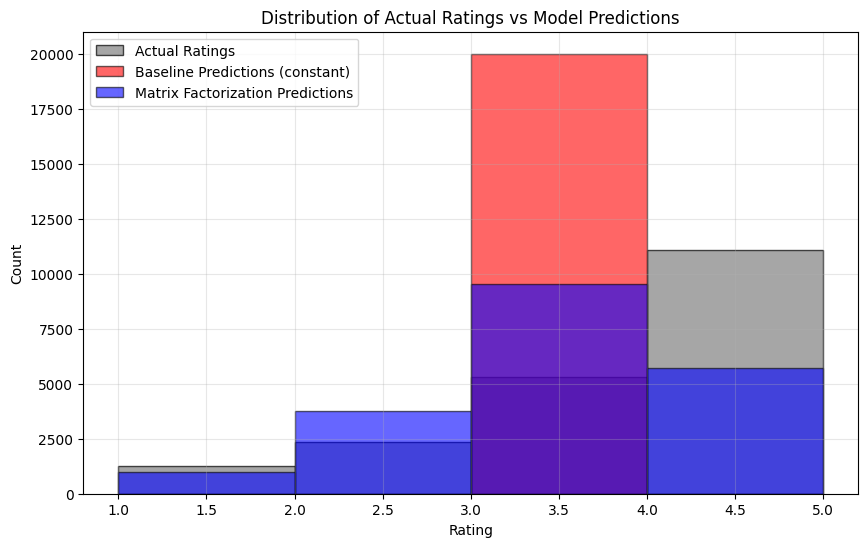

In [ ]:
import requests
import zipfile
from io import BytesIO
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
response = requests.get(url)
zip_file = zipfile.ZipFile(BytesIO(response.content))

with zip_file.open('ml-100k/u.data') as f:
    df = pd.read_csv(f, sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])

num_users = df['user_id'].max()
num_items = df['item_id'].max()
print(f"Loaded MovieLens 100K: {len(df):,} ratings, {num_users} users, {num_items} items")

np.random.seed(42)
train_df = df.sample(frac=0.8, random_state=42).copy()
test_df = df.drop(train_df.index).copy()

global_mean = train_df['rating'].mean()
print(f"Global mean baseline: {global_mean:.4f}")

def calculate_rmse(predictions, actuals):
    return np.sqrt(np.mean((np.array(predictions) - np.array(actuals)) ** 2))

baseline_rmse = calculate_rmse(np.full(len(test_df), global_mean), test_df['rating'].values)
print(f"Baseline RMSE: {baseline_rmse:.4f}")

class MatrixFactorization(nn.Module):
    def __init__(self, num_users, num_items, n_factors=20):
        super().__init__()
        self.user_factors = nn.Embedding(num_users, n_factors)
        self.item_factors = nn.Embedding(num_items, n_factors)
        self.user_bias = nn.Embedding(num_users, 1)
        self.item_bias = nn.Embedding(num_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

    def forward(self, user_ids, item_ids):
        user_emb = self.user_factors(user_ids - 1)
        item_emb = self.item_factors(item_ids - 1)
        dot = (user_emb * item_emb).sum(dim=1)
        ub = self.user_bias(user_ids - 1).squeeze()
        ib = self.item_bias(item_ids - 1).squeeze()
        return dot + ub + ib + self.global_bias

torch.manual_seed(42)
model = MatrixFactorization(num_users, num_items, n_factors=7)
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

train_users = torch.LongTensor(train_df['user_id'].values.copy())
train_items = torch.LongTensor(train_df['item_id'].values.copy())
train_ratings = torch.FloatTensor(train_df['rating'].values.copy())

print("Training Matrix Factorization")
for epoch in range(1000):
    optimizer.zero_grad()
    preds = model(train_users, train_items)
    loss = criterion(preds, train_ratings)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}  Loss: {loss.item():.4f}")

with torch.no_grad():
    test_users = torch.LongTensor(test_df['user_id'].values.copy())
    test_items = torch.LongTensor(test_df['item_id'].values.copy())
    test_preds = model(test_users, test_items)
    test_rmse = torch.sqrt(criterion(test_preds, torch.FloatTensor(test_df['rating'].values.copy()))).item()

print(f"\nMatrix Factorization Test RMSE: {test_rmse:.4f}")

print("\n=== Model Comparison ===")
print("| Model                    | Test RMSE|")
print("|--------------------------|----------|")
print(f"| Global Mean Baseline     | {baseline_rmse:.4f}   |")
print(f"| Matrix Factorization     | {test_rmse:.4f}   |")

plt.figure(figsize=(10, 6))
plt.hist(test_df['rating'].values, bins=range(1, 6), alpha=0.7, label='Actual Ratings', color='gray', edgecolor='black')
plt.hist(np.full(len(test_df), global_mean), bins=range(1, 6), alpha=0.6, label='Baseline Predictions (constant)', color='red', edgecolor='black')
plt.hist(test_preds.numpy().clip(1, 5), bins=range(1, 6), alpha=0.6, label='Matrix Factorization Predictions', color='blue', edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Distribution of Actual Ratings vs Model Predictions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Discussion of Challenges in Recommender Systems

The MovieLens 100K dataset is quite sparse: only about 6.3% of the possible user-item pairs have a rating (100,000 ratings out of roughly 943 x 1682 possible entries). This sparsity makes it difficult for simple models to learn reliable user or item representations.

Another important issue is popularity bias. A small number of movies (e.g., classics or blockbusters) receive the vast majority of ratings, while most movies have very few ratings. A global-mean baseline therefore tends to perform reasonably well on popular items but fails to capture nuanced preferences for less-rated (long-tail) movies.

Cold-start behavior is also present: new users or newly added movies have little or no rating history, so personalized models cannot yet make accurate recommendations for them without additional side information (genres, user demographics, etc.).

## Model Comparison

| Model                                      | Test RMSE | Improvement over Baseline |
|--------------------------------------------|-----------|---------------------------|
| Global Mean Baseline                       | 1.1303    | -                         |
| Matrix Factorization (n_factors=7, biases) | 1.0744    | 0.0559 (4.9% reduction)   |

The Matrix Factorization model clearly outperforms the simple baseline, confirming that learning latent user and item factors plus per-user and per-item biases captures meaningful signal beyond the overall average rating.







Here is the cleaned Markdown with all random bolds, italics, and em-dashes removed. You can paste it directly into your Colab notebook:

Cold-start behavior is also present: new users or newly added movies have little or no rating history, so personalized models cannot yet make accurate recommendations for them without additional side information (genres, user demographics, etc.).

## Where the Stronger Model Helps and Where It Still Struggles

Setting where Matrix Factorization helps:  
For users who have rated 20-100 movies (the majority of active users), the model learns personalized latent factors and biases effectively. It can distinguish subtle preferences (e.g., a user who likes sci-fi but dislikes horror) even when those movies are not extremely popular. This leads to more accurate rating predictions than simply using the global mean.

Setting where it still struggles:  
For cold-start users (users with very few or zero ratings) or extremely rare items (movies with fewer than 5 ratings), the model has almost no signal to learn good embeddings. In these cases, predictions often fall back close to the global mean or item bias, providing limited personalization. Additional techniques such as content-based features (movie genres), popularity-based fallback, or hybrid approaches would be needed to mitigate this limitation.


